In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import csv

In [29]:
# Data loading and preprocessing to adress the missalignment of columns in the CSV file
with open('user_courses_review_09_2023.csv', newline='') as f:
    reader = csv.reader(f)
    header = next(reader)
    rows = [row for row in reader if len(row) == 4]

In [30]:
# Load the dataset and update the 'review_rating' column to numeric
data = pd.DataFrame(rows, columns=header)
data['review_rating'] = pd.to_numeric(data['review_rating'], errors='coerce')
data = data.dropna(subset=['review_rating'])
data['review_rating'] = data['review_rating'].astype(int)
data.head()

,course_name,lecture_name,review_rating,review_comment
0,A/B Testing in Python,How to set up the A/B test,5,If she could provide more details about the pr...
1,A/B Testing in Python,How to set up the A/B test,5,nice
2,A/B Testing in Python,How to set up the A/B test,5,excellent course
3,A/B Testing in Python,How to set up the A/B test,5,nice
4,A/B Testing in Python,Conclusion,5,It was an experiential learning process


## Exploratory Data Analysis (EDA)

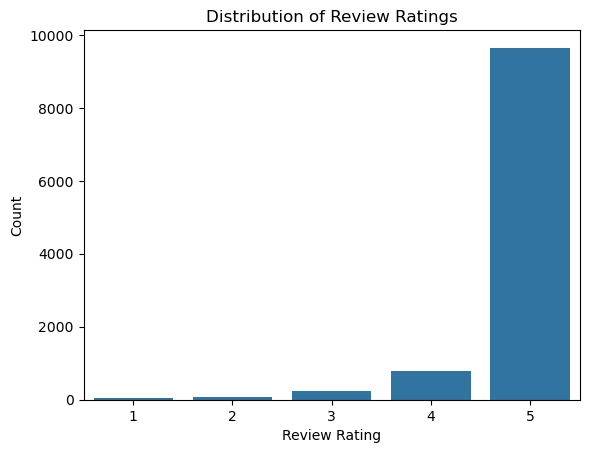

In [31]:
# Check the distribution of review ratings
sns.countplot(data=data, x='review_rating')
plt.xlabel('Review Rating')
plt.ylabel('Count')
plt.title('Distribution of Review Ratings')
plt.show()

The dataset is heavily imbalanced, with 5-star ratings dominating. This will be addressed during model training.

In [32]:
# Check for missing values
missing_values = data.isnull().sum()
missing_values

course_name       0
lecture_name      0
review_rating     0
review_comment    0
dtype: int64

In [33]:
data['label'] = data['review_rating'].apply(lambda x: 1 if x >= 4 else 0)
data.head()

,course_name,lecture_name,review_rating,review_comment,label
0,A/B Testing in Python,How to set up the A/B test,5,If she could provide more details about the pr...,1
1,A/B Testing in Python,How to set up the A/B test,5,nice,1
2,A/B Testing in Python,How to set up the A/B test,5,excellent course,1
3,A/B Testing in Python,How to set up the A/B test,5,nice,1
4,A/B Testing in Python,Conclusion,5,It was an experiential learning process,1


In [34]:
data['label'].value_counts()

label
1    10448
0      376
Name: count, dtype: int64

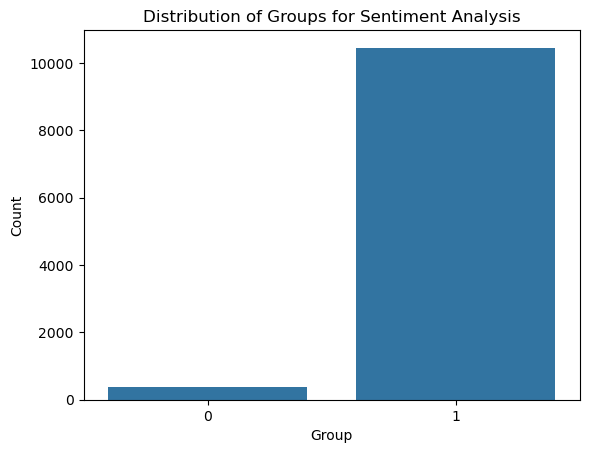

In [35]:
sns.countplot(data=data, x='label')
plt.xlabel('Group')
plt.ylabel('Count')
plt.title('Distribution of Groups for Sentiment Analysis')
plt.show()

The dataset is still heavily imbalanced. The data would need to split and class weights need to be added or oversample the bad review group (0) with SMOTE.

In [36]:
# Check for duplicate reviews
duplicate_count = data.duplicated(subset=['review_comment']).sum()
print(f"Duplicate review comments: {duplicate_count}")

# View the duplicates
data[data.duplicated(subset=['review_comment'], keep=False)].sort_values('review_comment').head(20)

Duplicate review comments: 3633


,course_name,lecture_name,review_rating,review_comment,label
5807,Introduction to Excel,Insert Hyperlinks into Excel Spreadsheets,5,,1
7547,Machine Learning in Excel,First Regression in Excel,5,,1
1704,Data Strategy,Using data for good,5,,1
2486,Git and GitHub,Branching,5,,1
2485,Git and GitHub,Branching,5,,1
1719,Data Strategy,Curating the most important data insights,5,,1
2479,Git and GitHub,Branching,5,,1
7576,Machine Learning in Excel,First Regression in Excel,4,,1
2476,Git and GitHub,Branching,5,,1
1752,Data Strategy,Using data for good,5,,1


Duplicate comments, particularly empty, short, or generic ones, were removed from the dataset. Such entries add little value to sentiment analysis and likely reflect copy-paste behavior. Single word or extremelly short reviews were also excluded, as they rarely provide meaningful signal and risk inflating model accuracy.

In [37]:
data = data.drop_duplicates(subset=['review_comment'])
print(f"Remaining reviews: {len(data)}")

Remaining reviews: 7191


In [38]:
data['label'].value_counts()

label
1    6844
0     347
Name: count, dtype: int64

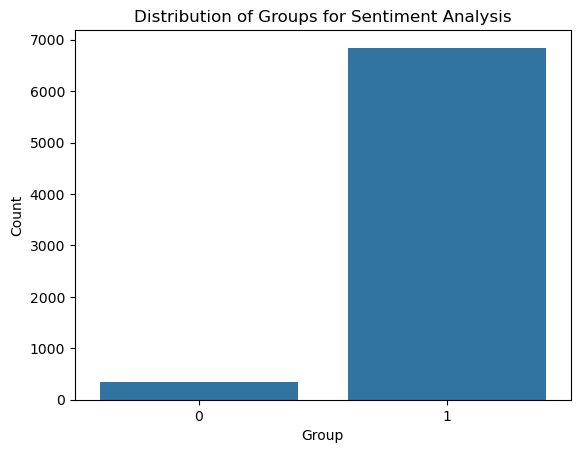

In [39]:
sns.countplot(data=data, x='label')
plt.xlabel('Group')
plt.ylabel('Count')
plt.title('Distribution of Groups for Sentiment Analysis')
plt.show()

Removing duplicates did not resolve the class imbalance, though it helped marginally as most removed comments were positive.